In [1]:
import getdist.plots as gdplt
import cobaya
from cobaya.yaml import yaml_load_file
from cobaya.run import run
import numpy as np
import os
from scipy import stats
import pandas as pd
from cobaya.yaml import yaml_dump_file
import shutil
import subprocess
import matplotlib.pyplot as plt
from getdist import MCSamples

In [11]:
import cobaya.likelihoods.bao.desi_dr2 as m
print(dir(m))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'desi_bao_all', 'desi_bao_bgs', 'desi_bao_elg2', 'desi_bao_lrg1', 'desi_bao_lrg2', 'desi_bao_lrg3pluselg1', 'desi_bao_lya', 'desi_bao_qso', 'desi_dr2']


In [10]:
from cobaya.likelihoods.bao.desi_dr2 import desi_bao_all
print(type(desi_bao_all))
print(desi_bao_all)

<class 'module'>
<module 'cobaya.likelihoods.bao.desi_dr2.desi_bao_all' from 'c:\\Users\\adrie\\anaconda3\\envs\\cobaya\\Lib\\site-packages\\cobaya\\likelihoods\\bao\\desi_dr2\\desi_bao_all.py'>


## Run sampler on $\Lambda \text{CDM}$ fake data

Use file named `w0=neg1_wa=0_n1.txt` in folder `fake_BAO_data`

to create some new data use script `Gen_BAO.py` and run with cmd : `conda run -n cobaya python .\Gen_BAO.py {Omega_m H0 w0 wa n, add_random}` with `n` the spec number of the file and `add_random` set to `True` to have randomness based on the cov. matrix and `False` to have exact value given by the model

In [ ]:
# for i in range(1):
#     subprocess.run(
#         ["conda", "run", "-n", "cobaya", "python", ".\Gen_BAO.py", "0.3", "70", "-1.0", "0", str(i+1), "False"],
#         check=True
#     )

<>:3: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:3: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\adrie\AppData\Local\Temp\ipykernel_19492\2089034413.py:3: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  ["conda", "run", "-n", "cobaya", "python", ".\Gen_BAO.py", "0.3", "70", "-1.0", "0", str(i+5), "False"],


In [45]:
# h = 0.7
# och2 = 0.123
# obh2 = 0.0224
# oc = och2/h**2
# ob = obh2/h**2
# Ob = 0.02236/(70/100)**2
# print(Ob)
# om = oc + ob
# print("Omega_c:", oc, "Omega_b:", ob, "Omega_m:", om)

In [44]:
# scale = 0.001
# # print piorr = stats.norm(loc=0, scale=scale)
# dist = stats.norm(loc=och2, scale=scale)
# plt.hist(dist.rvs(size=10000), bins=30, density=True)
# plt.xlabel("och2")
# plt.ylabel("Density")
# plt.title("Prior distribution for och2")

In [113]:
path = "C:/EPFL/MA4/code/fake_BAO_data/LCDM"
path += "/w0=neg1_wa=0_not_random.txt"
# path += "/w0=neg1_wa=0_n5.txt"

# load using pandas
# fake_data = pd.read_csv(path, header=None).values
# print(fake_data)

yaml_file = "cobaya_test_yaml/base_LCDM_input.yaml" #load yaml config file for LCDM
config = yaml_load_file(yaml_file)

config['likelihood']['bao.desi_dr2']['measurements_file'] = path
print(config['likelihood']['bao.desi_dr2']['measurements_file'])

config['output'] = "cobaya_test_runs/base_LCDM/LCDM_fakedata_not_random_H090"
config['sampler']['mcmc']['Rminus1_stop'] = 0.01

# print(config['params']['omch2'])
config['params']['H0']['value'] = 90
print(config['params']['H0'])


new_yaml = "cobaya_test_yaml/base_LCDM_fakedata_not_random_H0.yaml"
# new_yaml = "cobaya_test_yaml/base_LCDM_fakedata_n5.yaml"

# print(config['params'])

# save config file
overwrite = True
run = True

if os.path.exists(new_yaml) and overwrite:
    shutil.copy(new_yaml, new_yaml + ".bak")
    os.remove(new_yaml)
    
yaml_dump_file(new_yaml, config)

C:/EPFL/MA4/code/fake_BAO_data/LCDM/w0=neg1_wa=0_not_random.txt
{'value': 90, 'latex': 'H_0'}


To run the sampler : `cobaya-run .\cobaya_test_yaml\base_w_wa_input.yaml` add flag `--force` to overwrite on existing file or flag `--test` to test before laucnhing the sampling.

The yaml file must contain the path to the fake data, the output path, the priors and the value of fixed cosmological parameter like $H_0$

In [ ]:
if run:
    subprocess.run(
        ["conda", "run", "-n", "cobaya", "cobaya-run", new_yaml, "--test"],
        check=True
    )

In [114]:
if run:
    subprocess.run(
        ["conda", "run", "-n", "cobaya", "cobaya-run", new_yaml],
        check=True
    )

## cornerplot 

LCDM_fakedata_not_random_n1,2,3 are for Rminus1 at 0.01 and only one chain

In [44]:
path = r"C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM"
n = [1, 2, 3, 4, 5] # n1 n2 fake data 
n = [1, 2, 3] # n1 n2 fake data 
A = path + r"\LCDM_fakedata_n"
A = path + r"\LCDM_fakedata_not_random_n"
files = [A + str(i) + ".1.txt" for i in n]

### for different H0 ###
# A = path + r"\LCDM_fakedata_not_random_"
# files = [A + "H040.1.txt", A + "H050.1.txt", A + "H060.1.txt", A + "n1.1.txt", A + "H080.1.txt", A + "H090.1.txt"]
########################

sampler = [[] for i in range(len(files))]
samples = [[] for i in range(len(files))]

names = [r"hr_\mathrm{drag}", r"\Omega_m"] # --> 2 et 6
# names = [r"hr_\mathrm{drag}", r"\Omega_ch^2", r"\Omega_m"] # --> 2, 3 et 6

for i in range(len(files)):
    print("File", i, ":", files[i])
    sampler[i] = np.loadtxt(files[i])
    dat = [sampler[i][:, 2], sampler[i][:, 6]]
    # dat = [sampler[i][:, 2], sampler[i][:, 3], sampler[i][:, 6]]
    dat = np.array(dat)
    samples[i] = dat.T

File 0 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_n1.1.txt
File 1 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_n2.1.txt
File 2 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_n3.1.txt


### plot

Samples shape 0 : (2160, 2)
Samples shape 1 : (3080, 2)
Samples shape 2 : (1120, 2)


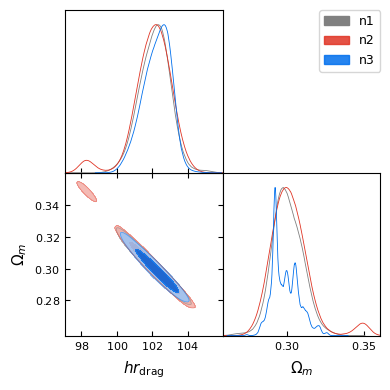

In [26]:
from getdist import MCSamples
# print(samples.shape)
gd_sample = [[] for _ in range(len(samples))]

for i in range(len(samples)):
    print("Samples shape", i, ":", samples[i].shape)
    gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

### cut burn in and plot

(1512, 2)
Samples shape 0 : (2160, 2)
Taking last 1512 samples
(2156, 2)
Samples shape 1 : (3080, 2)
Taking last 2156 samples
(784, 2)
Samples shape 2 : (1120, 2)
Taking last 784 samples
Eff. Sample Size for run 1: 369, with sample size : 2160 ratio : 0.17
Eff. Sample Size for run 2: 585, with sample size : 3080 ratio : 0.19
Eff. Sample Size for run 3: 238, with sample size : 1120 ratio : 0.21


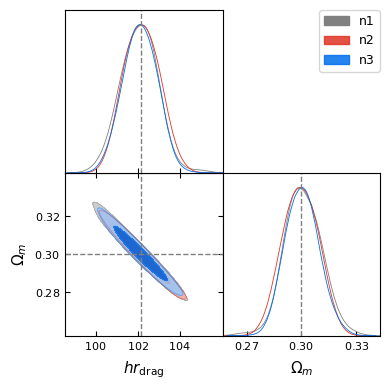

In [45]:
from getdist import MCSamples
# print(samples.shape)
# for i in range(len(samples)):

#     gdplot = gdplt.get_subplot_plotter()
#     gdplot.triangle_plot(gd_sample, names, filled=True)

# labelH0 = ["H0=40", "H0=50", "H0=60", "H0=70", "H0=80", "H0=90"]

for i in range(len(samples)):
    n = samples[i].shape[0] * 0.7
    n = int(n)
    sampl = samples[i][-n:]
    print(sampl.shape)
    print("Samples shape", i, ":", samples[i].shape)
    print("Taking last", n, "samples")
    gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label='n'+str(i+1))
    # gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label=labelH0[i])

    # gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3},
                     marker_args={"lw": 1})

eff_size_all = [sample.getEffectiveSamples() for sample in gd_sample]
for i in range(len(samples)):
    print(f"Eff. Sample Size for run {i+1}: {round(eff_size_all[i])}, with sample size : {samples[i].shape[0]}",
          f"ratio : {round(eff_size_all[i]/samples[i].shape[0], 2)}")

Expected values are $\Omega_m = 0.3$ and $hr_d = 102 \ h^{-1}\text{Mpc}$

In [25]:
from getdist import loadMCSamples

# Get effective sample size for all samples
eff_size = [sample.getEffectiveSamples() for sample in gd_sample]

# Get effective sample size for a specific parameter
eff_size_param = [sample.getEffectiveSamples(names[1]) for sample in gd_sample]

print(f"Effective Sample Size: {', '.join(str(round(eff_size[i])) for i in range(len(gd_sample)))}")
print(f"Effective Sample Size for {names[1]}: {', '.join(str(round(eff_size_param[i])) for i in range(len(gd_sample)))}")

Effective Sample Size: 369, 585, 238
Effective Sample Size for \Omega_m: 365, 545, 224


## test MPI implementation

MPItest is done with Rminus1 = 0.05, 
MPItest: 
- **2** with Rminus1 = 0.01, **3** is similar to 2, 
- **4** Rminus1 set to 0.005,  **5** similar to 4, **6** similar to 4
- **7** is similar to 2 and 3 for more stat
- **8**, **9** and **10** Rminus1 set to 0.001
- **11** to **14** Rminus1 set to 0.001 as above but covmat has been specified to that produced by run 10
- **15** to **17** same as above but we'll vary the covmat file

### individual chains

In [58]:
path = r"C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5."
ranks = [1, 2, 3, 4]
files = [path + str(i) + ".txt" for i in ranks]

samples = [[] for _ in range(len(ranks))]

names = [r"hr_\mathrm{drag}", r"\Omega_m"] # --> 2 et 6
# names = [r"hr_\mathrm{drag}", r"\Omega_ch^2", r"\Omega_m"] # --> 2, 3 et 6

for i in range(len(files)):
    print("File", i, ":", files[i])
    truc = np.loadtxt(files[i])
    dat = [truc[:, 2], truc[:, 6]]
    # dat = [truc[:, 2], truc[:, 3], truc[:, 6]]
    dat = np.array(dat)
    samples[i] = dat.T

File 0 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5.1.txt
File 1 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5.2.txt
File 2 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5.3.txt
File 3 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5.4.txt


Samples shape 0 : (1960, 2)
Samples shape 1 : (1953, 2)
Samples shape 2 : (1928, 2)
Samples shape 3 : (1922, 2)


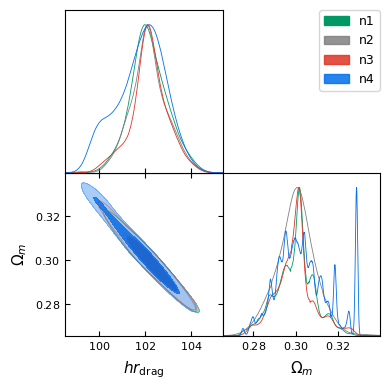

In [59]:
gd_sample = [[] for _ in range(len(samples))]

for i in range(len(samples)):
    print("Samples shape", i, ":", samples[i].shape)
    gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

(1372, 2)
Samples shape 0 : (1960, 2)
Taking last 1372 samples
(1367, 2)
Samples shape 1 : (1953, 2)
Taking last 1367 samples
(1349, 2)
Samples shape 2 : (1928, 2)
Taking last 1349 samples
(1345, 2)
Samples shape 3 : (1922, 2)
Taking last 1345 samples


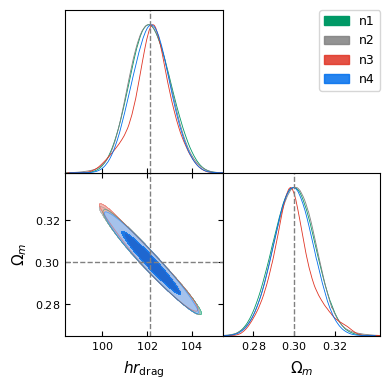

In [60]:
from getdist import MCSamples
# print(samples.shape)
# for i in range(len(samples)):

#     gdplot = gdplt.get_subplot_plotter()
#     gdplot.triangle_plot(gd_sample, names, filled=True)

# labelH0 = ["H0=40", "H0=50", "H0=60", "H0=70", "H0=80", "H0=90"]

samples_clean = []
for i in range(len(samples)):
    n = samples[i].shape[0] * 0.7
    n = int(n)
    sampl = samples[i][-n:]
    samples_clean.append(sampl)
    print(sampl.shape)
    print("Samples shape", i, ":", samples[i].shape)
    print("Taking last", n, "samples")
    gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label='n'+str(i+1))
    # gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label=labelH0[i])

    # gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))
all_samples_clean = np.concatenate(samples_clean, axis=0)

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3},
                     marker_args={"lw": 1})

In [70]:
# Get effective sample size for all samples
eff_size = [sample.getEffectiveSamples() for sample in gd_sample]   
print(f"Effective Sample Size: {', '.join(str(round(eff_size[i])) for i in range(len(gd_sample)))}")

Effective Sample Size: 256, 192, 180, 233


### combined chains

In [99]:
# runs = [2, 3, 7]
runs = [4, 5, 6]
runs = [8, 9, 10]
runs = [11, 12, 13, 14]
runs = [11, 15, 16]

all_samples = [[] for _ in range(len(runs))]
all_samples_clean = [[] for _ in range(len(runs))]
sample_eff_size = [[] for _ in range(len(runs))]
sample_eff_size_clean = [[] for _ in range(len(runs))]

for j in range(len(runs)):
    path = r"C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest" + str(runs[j]) + "."
    files = [path + str(i) + ".txt" for i in range(1, 5)]
    ranks = [1, 2, 3, 4]

    samples = [[] for _ in range(len(ranks))]
    samples_clean = [[] for _ in range(len(ranks))]

    names = [r"hr_\mathrm{drag}", r"\Omega_m"] # --> 2 et 6
    # names = [r"hr_\mathrm{drag}", r"\Omega_ch^2", r"\Omega_m"] # --> 2, 3 et 6

    for i in range(len(files)):
        print("File", i, ":", files[i])
        truc = np.loadtxt(files[i])
        dat = [truc[:, 2], truc[:, 6]]
        # dat = [truc[:, 2], truc[:, 3], truc[:, 6]]
        dat = np.array(dat)
        samples[i] = dat.T
        n = samples[i].shape[0] * 0.7
        n = int(n)
        samples_clean[i] = samples[i][-n:]
        sample_eff_size[j].append(MCSamples(samples=samples[i], names=names, labels=names, label='n'+str(i+1)).getEffectiveSamples())
        sample_eff_size_clean[j].append(MCSamples(samples=samples_clean[i], names=names, labels=names, label='n'+str(i+1)).getEffectiveSamples())
    
    # for s in samples:
    #     print(s.shape)
    # print(sum(samples[i].shape[0] for i in range(len(samples))))
    all_samples[j] = np.concatenate(samples, axis=0)
    # print(len(all_samples[j]))
    all_samples_clean[j] = np.concatenate(samples_clean, axis=0)

File 0 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest11.1.txt
File 1 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest11.2.txt
File 2 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest11.3.txt
File 3 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest11.4.txt
File 0 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest15.1.txt
File 1 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest15.2.txt
File 2 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest15.3.txt
File 3 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest15.4.txt
File 0 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest16.1.txt
File 1 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest16.2.txt
File 2 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fa

In [100]:
for j in range(len(runs)):
    print(f"Run {runs[j]} : sum of individual effective sample sizes : {round(sum(sample_eff_size[j]))}",
          f", sum of effective sample sizes after burn in cutoff : {round(sum(sample_eff_size_clean[j]))}")

Run 11 : sum of individual effective sample sizes : 4298 , sum of effective sample sizes after burn in cutoff : 3155
Run 15 : sum of individual effective sample sizes : 2926 , sum of effective sample sizes after burn in cutoff : 1970
Run 16 : sum of individual effective sample sizes : 4506 , sum of effective sample sizes after burn in cutoff : 3264


Effective Sample Size for all samples: 4443, for 70%: 3236


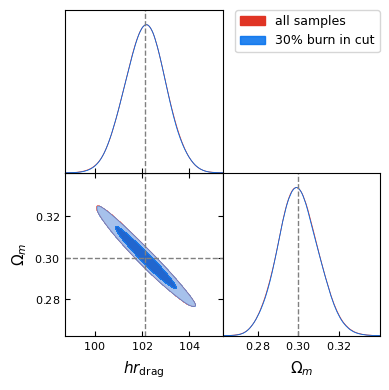

In [103]:
k = 2

gd_all_sample = [MCSamples(samples=all_samples[k], names=names, labels=names, label='all samples'), 
                 MCSamples(samples=all_samples_clean[k], names=names, labels=names, label='30% burn in cut')] # whole chains, burn in cut

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_all_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3},
                     marker_args={"lw": 1})

eff_size_all = [sample.getEffectiveSamples() for sample in gd_all_sample]
print(f"Effective Sample Size for all samples: {round(eff_size_all[0])}, for 70%: {round(eff_size_all[1])}")

Eff. Sample Size for run 11: 4283 with sample size : 13024 ratio : 0.33
Eff. Sample Size for run 15: 2860 with sample size : 8255 ratio : 0.35
Eff. Sample Size for run 16: 4443 with sample size : 14569 ratio : 0.3
for combined chains but with burn in cutoff


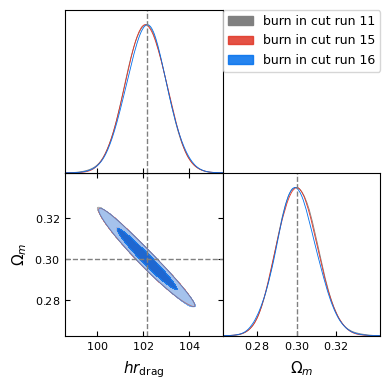

In [102]:
# gd_all_sample = [MCSamples(samples=all_samples_clean[i], names=names, labels=names, label='burn in cut run '+str(runs[i]))
gd_all_sample = [MCSamples(samples=all_samples[i], names=names, labels=names, label='burn in cut run '+str(runs[i]))
                 for i in range(len(runs))] # whole chains, burn in cut 

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_all_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3},
                     marker_args={"lw": 1})

eff_size_all = [sample.getEffectiveSamples() for sample in gd_all_sample]
for i in range(len(runs)):
    print(f"Eff. Sample Size for run {runs[i]}: {round(eff_size_all[i])} with sample size : {all_samples_clean[i].shape[0]}",
          f"ratio : {round(eff_size_all[i]/all_samples_clean[i].shape[0], 2)}")
print("for combined chains but with burn in cutoff")

# test $w_0w_a\text{CDM}$ using Cobaya sampling on DESI DR2 data

In [ ]:
path = r"C:\EPFL\MA4\code\cobaya_test_runs\base_w_wa"
file1= path + r"\test1_H0=70.1.txt"
# file3 = path + r"\Om_hrdrag_test_ref.1.txt"
# H0_ = [20, 30, 40, 50, 60, 70, 80, 90, 100]
# filename = path + r"\Om_hrdrag_H0=90"
# files_H0 = [path + r"\Om_hrdrag_H0=" + str(H) + r".1.txt" for H in H0_]

sampler = np.loadtxt(file1)
names = [r"hr_\mathrm{drag}", "w_0", "w_a", r"\Omega_m"]
samples = [sampler[:, 2], sampler[:, 4], sampler[:, 5], sampler[:, 8]]

nsamples = len(samples[0])
print("There are {} samples".format(nsamples))
n = int(4*nsamples/5)
print("Taking the last {} samples".format(n))
samples = [samples[i][-n:] for i in range(len(samples))]

samples = np.array(samples)
samples = samples.T

There are 8760 samples
Taking the last 7008 samples


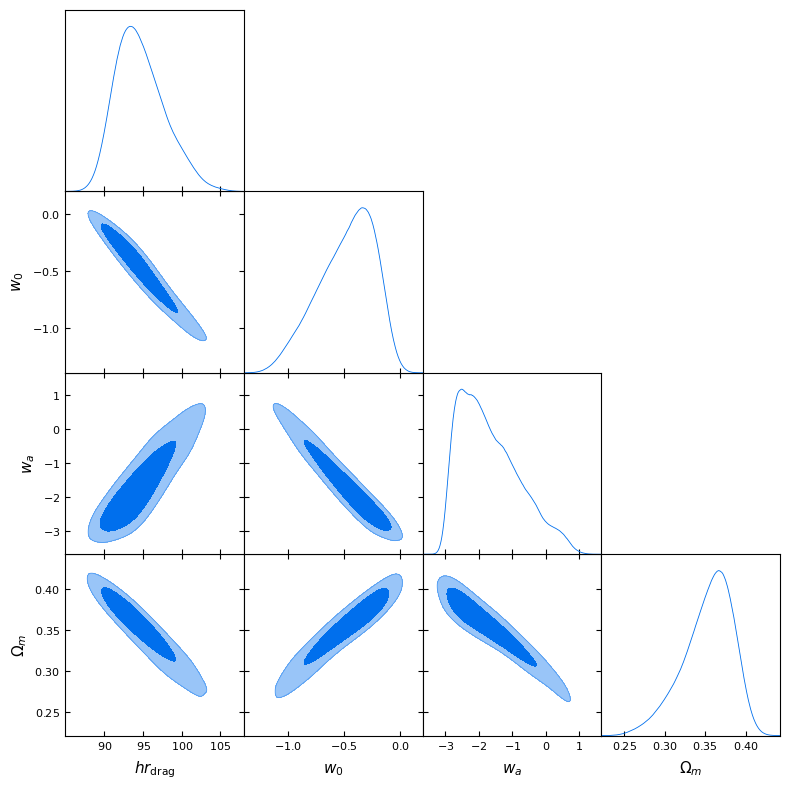

In [100]:
from getdist import MCSamples
gd_sample = MCSamples(samples=samples, names=names, labels=names)
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

### individual chains

In [ ]:
path = r"C:\EPFL\MA4\code\cobaya_test_runs\base_w_wa\LCDM_fakedata_not_random_1."
ranks = [1, 2, 3, 4]
files = [path + str(i) + ".txt" for i in ranks]

samples = [[] for _ in range(len(ranks))]

names = [r"hr_\mathrm{drag}", r"\Omega_m"] # --> 2 et 6
# names = [r"hr_\mathrm{drag}", r"\Omega_ch^2", r"\Omega_m"] # --> 2, 3 et 6

for i in range(len(files)):
    print("File", i, ":", files[i])
    truc = np.loadtxt(files[i])
    dat = [truc[:, 2], truc[:, 6]]
    # dat = [truc[:, 2], truc[:, 3], truc[:, 6]]
    dat = np.array(dat)
    samples[i] = dat.T

File 0 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5.1.txt
File 1 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5.2.txt
File 2 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5.3.txt
File 3 : C:\EPFL\MA4\code\cobaya_test_runs\base_LCDM\LCDM_fakedata_not_random_MPItest5.4.txt


Samples shape 0 : (1960, 2)
Samples shape 1 : (1953, 2)
Samples shape 2 : (1928, 2)
Samples shape 3 : (1922, 2)


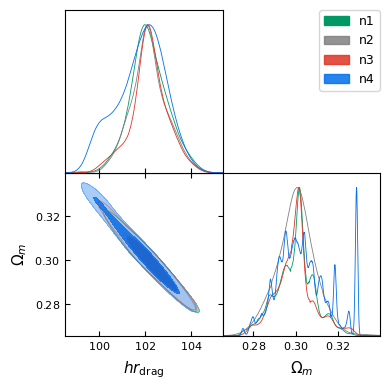

In [ ]:
gd_sample = [[] for _ in range(len(samples))]

for i in range(len(samples)):
    print("Samples shape", i, ":", samples[i].shape)
    gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

(1372, 2)
Samples shape 0 : (1960, 2)
Taking last 1372 samples
(1367, 2)
Samples shape 1 : (1953, 2)
Taking last 1367 samples
(1349, 2)
Samples shape 2 : (1928, 2)
Taking last 1349 samples
(1345, 2)
Samples shape 3 : (1922, 2)
Taking last 1345 samples


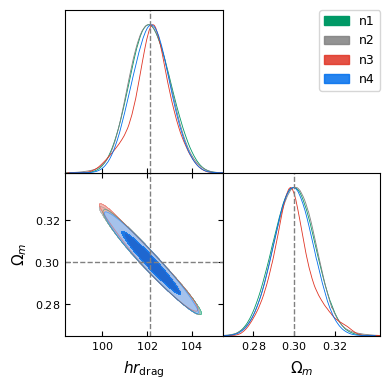

In [ ]:
from getdist import MCSamples
# print(samples.shape)
# for i in range(len(samples)):

#     gdplot = gdplt.get_subplot_plotter()
#     gdplot.triangle_plot(gd_sample, names, filled=True)

# labelH0 = ["H0=40", "H0=50", "H0=60", "H0=70", "H0=80", "H0=90"]

samples_clean = []
for i in range(len(samples)):
    n = samples[i].shape[0] * 0.7
    n = int(n)
    sampl = samples[i][-n:]
    samples_clean.append(sampl)
    print(sampl.shape)
    print("Samples shape", i, ":", samples[i].shape)
    print("Taking last", n, "samples")
    gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label='n'+str(i+1))
    # gd_sample[i] = MCSamples(samples=sampl, names=names, labels=names, label=labelH0[i])

    # gd_sample[i] = MCSamples(samples=samples[i], names=names,  labels=names, label='n'+str(i+1))
all_samples_clean = np.concatenate(samples_clean, axis=0)

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3},
                     marker_args={"lw": 1})

In [ ]:
# Get effective sample size for all samples
eff_size = [sample.getEffectiveSamples() for sample in gd_sample]   
print(f"Effective Sample Size: {', '.join(str(round(eff_size[i])) for i in range(len(gd_sample)))}")

Effective Sample Size: 256, 192, 180, 233


### combined chains

In [104]:
runs = [1]

all_samples = [[] for _ in range(len(runs))]
all_samples_clean = [[] for _ in range(len(runs))]
sample_eff_size = [[] for _ in range(len(runs))]
sample_eff_size_clean = [[] for _ in range(len(runs))]

for j in range(len(runs)):
    path = r"C:\EPFL\MA4\code\cobaya_test_runs\base_w_wa\LCDM_fakedata_not_random_" + str(runs[j]) + "."
    files = [path + str(i) + ".txt" for i in range(1, 5)]
    ranks = [1, 2, 3, 4]

    samples = [[] for _ in range(len(ranks))]
    samples_clean = [[] for _ in range(len(ranks))]

    names = [r"hr_\mathrm{drag}", "w_0", "w_a", r"\Omega_m"] # --> 2 et 6

    for i in range(len(files)):
        print("File", i, ":", files[i])
        truc = np.loadtxt(files[i])
        dat = [truc[:, 2], truc[:, 4], truc[:, 5], truc[:, 8]]
        # dat = [truc[:, 2], truc[:, 3], truc[:, 6]]
        dat = np.array(dat)
        samples[i] = dat.T
        n = samples[i].shape[0] * 0.7
        n = int(n)
        samples_clean[i] = samples[i][-n:]
        sample_eff_size[j].append(MCSamples(samples=samples[i], names=names, labels=names, label='n'+str(i+1)).getEffectiveSamples())
        sample_eff_size_clean[j].append(MCSamples(samples=samples_clean[i], names=names, labels=names, label='n'+str(i+1)).getEffectiveSamples())
    
    # for s in samples:
    #     print(s.shape)
    # print(sum(samples[i].shape[0] for i in range(len(samples))))
    all_samples[j] = np.concatenate(samples, axis=0)
    # print(len(all_samples[j]))
    all_samples_clean[j] = np.concatenate(samples_clean, axis=0)

File 0 : C:\EPFL\MA4\code\cobaya_test_runs\base_w_wa\LCDM_fakedata_not_random_1.1.txt
File 1 : C:\EPFL\MA4\code\cobaya_test_runs\base_w_wa\LCDM_fakedata_not_random_1.2.txt
File 2 : C:\EPFL\MA4\code\cobaya_test_runs\base_w_wa\LCDM_fakedata_not_random_1.3.txt
File 3 : C:\EPFL\MA4\code\cobaya_test_runs\base_w_wa\LCDM_fakedata_not_random_1.4.txt


In [105]:
for j in range(len(runs)):
    print(f"Run {runs[j]} : sum of individual effective sample sizes : {round(sum(sample_eff_size[j]))}",
          f", sum of effective sample sizes after burn in cutoff : {round(sum(sample_eff_size_clean[j]))}")

Run 1 : sum of individual effective sample sizes : 3678 , sum of effective sample sizes after burn in cutoff : 2739


Effective Sample Size for all samples: 3669, for 70%: 2812


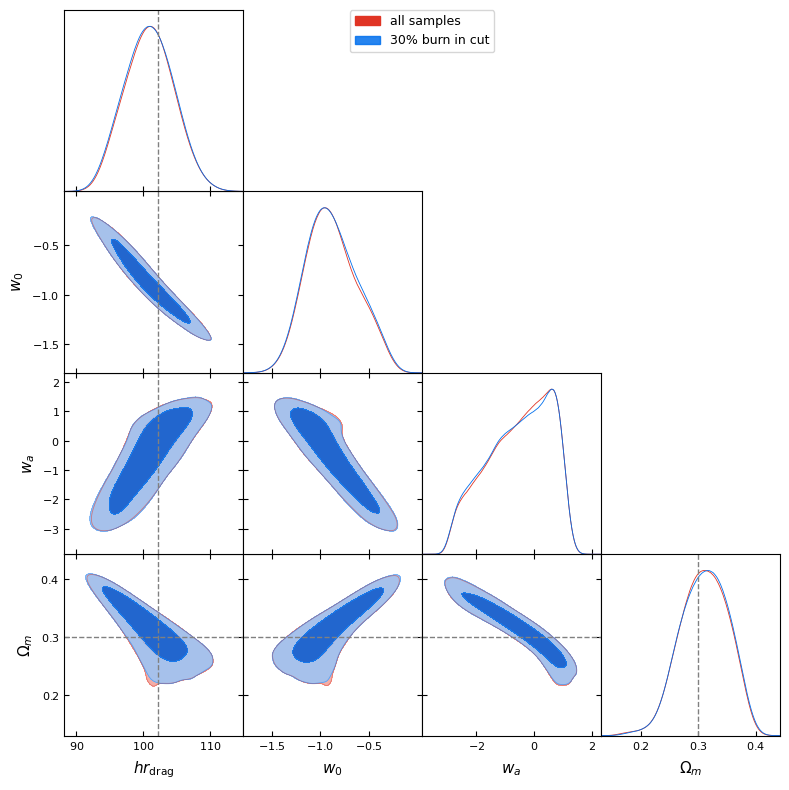

In [106]:
k = 0

gd_all_sample = [MCSamples(samples=all_samples[k], names=names, labels=names, label='all samples'), 
                 MCSamples(samples=all_samples_clean[k], names=names, labels=names, label='30% burn in cut')] # whole chains, burn in cut

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_all_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3},
                     marker_args={"lw": 1})

eff_size_all = [sample.getEffectiveSamples() for sample in gd_all_sample]
print(f"Effective Sample Size for all samples: {round(eff_size_all[0])}, for 70%: {round(eff_size_all[1])}")

Eff. Sample Size for run 1: 2812 with sample size : 56128 ratio : 0.05
for combined chains but with burn in cutoff


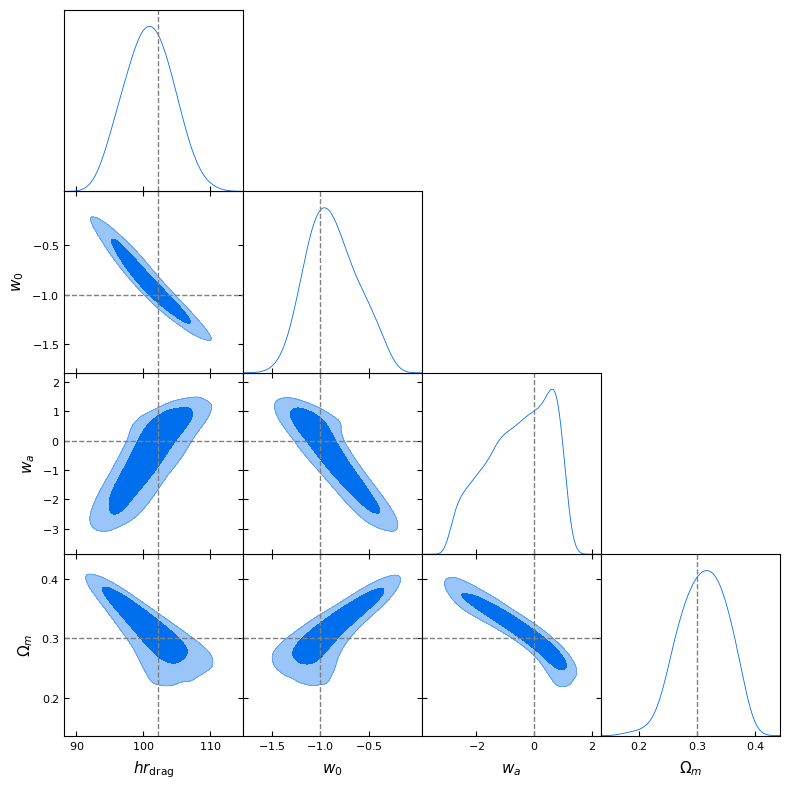

In [108]:
gd_all_sample = [MCSamples(samples=all_samples_clean[i], names=names, labels=names, label='burn in cut run '+str(runs[i]))
# gd_all_sample = [MCSamples(samples=all_samples[i], names=names, labels=names, label='burn in cut run '+str(runs[i]))
                 for i in range(len(runs))] # whole chains, burn in cut 

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_all_sample, names, filled=True,
                     markers={names[0]: 102.15 , r'\Omega_m': 0.3, r'w_0': -1, r'w_a': 0},
                     marker_args={"lw": 1})

eff_size_all = [sample.getEffectiveSamples() for sample in gd_all_sample]
for i in range(len(runs)):
    print(f"Eff. Sample Size for run {runs[i]}: {round(eff_size_all[i])} with sample size : {all_samples_clean[i].shape[0]}",
          f"ratio : {round(eff_size_all[i]/all_samples_clean[i].shape[0], 2)}")
print("for combined chains but with burn in cutoff")

# plot of individual redshift DESI data

## $\Lambda\mathrm{CDM}$

in folder ``cobaya_runs\DESI_data\LCDM_individual`` are stored MCMC chains on individua redshifted denoted ``z1`` $z=0.295$ to ``z7`` $z = 2.33$

In [26]:
########### creating the config files#####################3

overwrite = False

path = r"C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2"
files = os.listdir(path)
os.listdir(path)
files = [f for f in os.listdir(path) if f.endswith("_mean.txt")]
files = files[1:]
redshifts = [2, 3, 4, 5, 6, 7]
for z in redshifts:
    # config = yaml_load_file("config_files/DESI_data/LCDM_individual/z1.yaml")
    config = yaml_load_file("config_files/DESI_data/w_wa_individual/z1.yaml")
    filename = files[z-1]
    config['likelihood']['bao.desi_dr2']['measurements_file'] = f"C:/EPFL/MA4/code/COBAYA_packages/data/bao_data/desi_bao_dr2/{filename}"
    filename_cov = filename.replace("_mean.txt", "_cov.txt")
    config['likelihood']['bao.desi_dr2']['cov_file'] = f"C:/EPFL/MA4/code/COBAYA_packages/data/bao_data/desi_bao_dr2/{filename_cov}"
    config['output'] = f"cobaya_runs/DESI_data/w_wa_individual/z{z}/z{z}"
    config['sampler']['mcmc']['Rminus1_stop'] = 0.05
    # if os.path.exists(f"config_files/DESI_data/LCDM_individual/z{z}.yaml") and overwrite:
    #     os.remove(f"config_files/DESI_data/LCDM_individual/z{z}.yaml")
    # yaml_dump_file(f"config_files/DESI_data/LCDM_individual/z{z}.yaml", config)
    if os.path.exists(f"config_files/DESI_data/w_wa_individual/z{z}.yaml") and overwrite:
        os.remove(f"config_files/DESI_data/w_wa_individual/z{z}.yaml")
    yaml_dump_file(f"config_files/DESI_data/w_wa_individual/z{z}.yaml", config)
 

KeyError: 'bao.desi_dr2'

In [94]:
from cobaya import load_samples
redshifts = [1, 2, 3, 4, 5, 6, 7]
# redshifts = [1, 2, 3, 4, 5, 6]
z_values = [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330]
# redshifts = [3]

gd_sample = [load_samples(f"cobaya_runs/DESI_data/LCDM_individual/z{z}/z{z}", to_getdist=True, skip=0) for z in redshifts]

names = ["hrdrag", "omm"] 

In [ ]:
# Analyze and plot
# for samp in gd_sample:
#     mean = samp.getMeans()[:2]
#     covmat = samp.getCovMat().matrix[:2, :2]
#     print("Mean:")
#     print(mean)
#     print("Covariance matrix:")
#     print(covmat)

import getdist.plots as gdplt

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, [names[0], names[1]], filled=True, legend_labels=[r"$z_\mathrm{eff}=" + str(z) + r"$" for z in z_values])

UsageError: unrecognized arguments: # uncomment if running from the Jupyter notebook


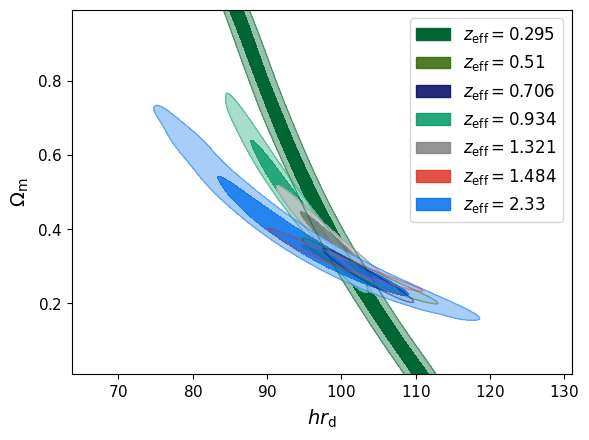

In [ ]:
gdplot = gdplt.get_single_plotter()
gdplot.plot_2d(gd_sample, [names[0], names[1]], filled=True, width_inch=4)
gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$" for z in z_values])

## $w_0w_a\mathrm{CDM}$

In [57]:
from cobaya import load_samples
redshifts = [1, 2, 3, 4, 5, 6, 7]
redshifts = [1, 2, 3, 4, 5]
redshifts = [7]
z_values = [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330]
zvalues = [z_values[i-1] for i in redshifts]

gd_sample = [load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z{z}/z{z}", to_getdist=True, skip=0) for z in redshifts]

names = ["hrdrag", "w", "wa", "omm"] 

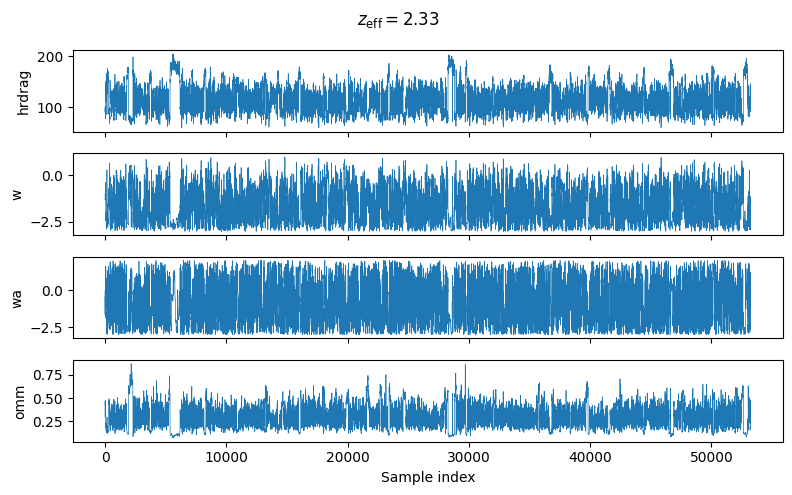

In [58]:
import matplotlib.pyplot as plt
import numpy as np

for sample, z in zip(gd_sample, zvalues):
    fig, axes = plt.subplots(4, 1, figsize=(8, 5), sharex=True)
    fig.suptitle(rf"$z_\mathrm{{eff}}={z}$", fontsize=12)

    for j, name in enumerate(names):
        chain = sample.samples[:, sample.index[name]]
        axes[j].plot(np.arange(len(chain)), chain, linewidth=0.5)
        axes[j].set_ylabel(name, fontsize=10)

    axes[-1].set_xlabel("Sample index", fontsize=10)
    plt.tight_layout()
    plt.show()

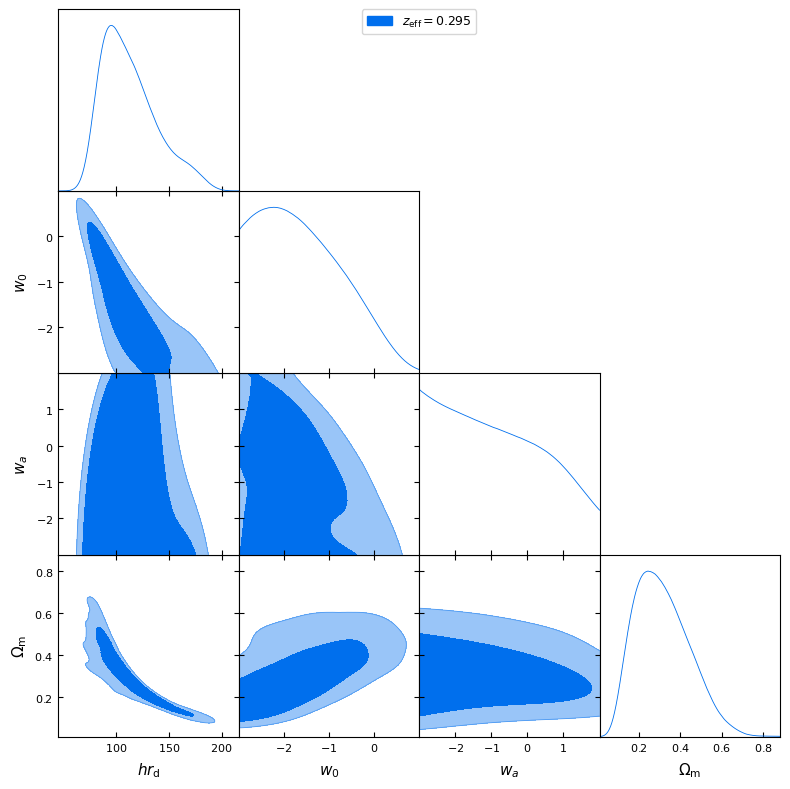

In [59]:
# Analyze and plot
# for samp in gd_sample:
#     mean = samp.getMeans()[:2]
#     covmat = samp.getCovMat().matrix[:2, :2]
#     print("Mean:")
#     print(mean)
#     print("Covariance matrix:")
#     print(covmat)

import getdist.plots as gdplt

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True, legend_labels=[r"$z_\mathrm{eff}=" + str(z) + r"$" for z in z_values])

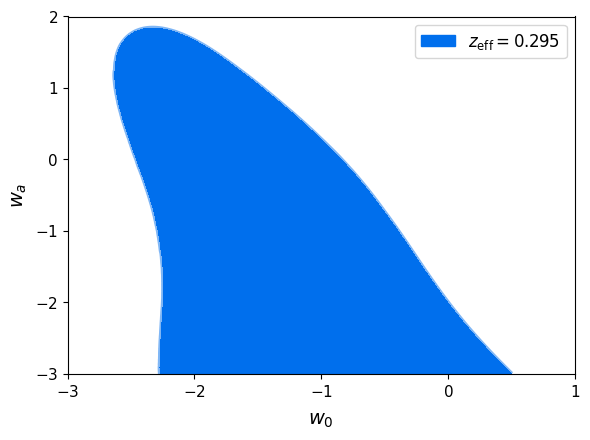

In [ ]:
gdplot = gdplt.get_single_plotter()
gdplot.settings.alpha_filled_add = 0.5  # more transparent fill
# gdplot.settings.alpha_factor_contour_lines = 1  
gdplot.settings.linewidth_contour = 2.0
gdplot.settings.num_plot_contours = 1
gdplot.plot_2d(gd_sample, [names[1], names[2]], filled=True, width_inch=4)
gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$" for z in z_values])


In [12]:
gdplot.settings.alpha_filled_add = 0.25  # more transparent fill
gdplot.settings.linewidth = 2.0          # thicker outlines
gdplot.plot_2d(gd_sample, [names[1], names[2]], filled=True, width_inch=4)

((-3.0, 1.0), (-3.0, 2.0))

## GIF

#### $\Omega_m - hr_d$ contours with model $\Lambda\mathrm{CDM}$

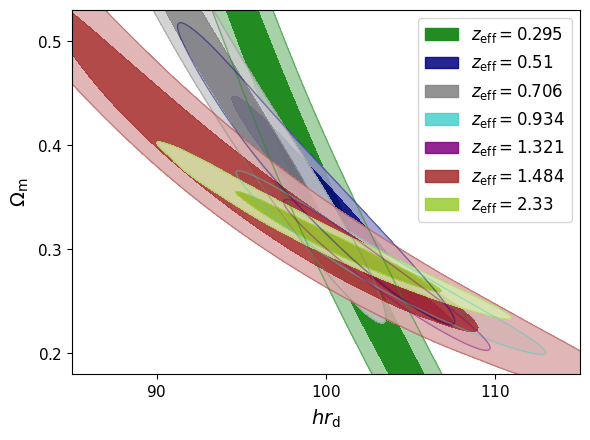

In [9]:
from cobaya import load_samples
redshifts = [1, 2, 3, 4, 5, 6, 7]
# redshifts = [1, 2, 3, 4, 5, 6]
z_values = [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330]
colors = ['forestgreen', 'navy', 'gray', 'mediumturquoise', 'purple', 'brown', 'yellowgreen']

gd_sample = [load_samples(f"cobaya_runs/DESI_data/LCDM_individual/z{z}/z{z}", to_getdist=True, skip=0) for z in redshifts]
new_order = [0, 4, 3, 1, 2, 6, 5]
gd_sample = [gd_sample[i] for i in new_order]

names = ["hrdrag", "omm"] 

for i in range(len(redshifts)):
    if i ==6:
        gdplot = gdplt.get_single_plotter()
        # gdplot.plot_2d(gd_sample[0:i+1], [names[0], names[1]], filled=True, width_inch=4, colors=colors, lims=[74, 120, 0.05, 0.95])
        gdplot.plot_2d(gd_sample[0:i+1], [names[0], names[1]], filled=True, width_inch=4, colors=colors, lims=[85, 115, 0.18, 0.53])
        gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$" for z in z_values])
        # gdplot.export(f"figures/DESI_data/LCDM_individual/contours_Om_hrd_{redshifts[i]}.png")

#### gif maker

In [ ]:
# import imageio
# import glob

# # Save your pngs first (sorted so the gif is in order)
# frames = sorted(glob.glob("figures/DESI_data/LCDM_individual/contours_Om_hrd_*.png"))

# with imageio.get_writer("figures/DESI_data/LCDM_individual/contours_Om_hrd.gif", mode="I", duration=750.0, loop=0) as writer:
#     for frame in frames:
#         writer.append_data(imageio.imread(frame))

C:\Users\adrie\AppData\Local\Temp\ipykernel_13944\1183731249.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame))


#### $w_0 - w_a$ contours

In [ ]:
from cobaya import load_samples
redshifts = [1, 2, 3, 4, 5, 6, 7]
# redshifts = [7]
z_values = [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330]
zvalues = [z_values[i-1] for i in redshifts]

gd_sample = [load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z{z}/z{z}", to_getdist=True, skip=0.33) for z in redshifts]
gd_sample[0] = load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z1/z1_2", to_getdist=True, skip=0.33)
gd_sample[0] = load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z1/z1_3", to_getdist=True, skip=0.33)
# gd_sample[1] = load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z2/z2_2", to_getdist=True, skip=0.33)
gd_sample = [gd_sample[i] for i in new_order]

names = ["hrdrag", "w", "wa", "omm"] 

k=1
for sample, z in zip(gd_sample, zvalues):
    gdplot = gdplt.get_single_plotter()
    gdplot.settings.alpha_filled_add = 1
    # gdplot.settings.alpha_factor_contour_lines = 1  
    # gdplot.settings.linewidth_contour = 2.0
    gdplot.settings.num_plot_contours = 2
    gdplot.plot_2d(sample, [names[1], names[2]], filled=True, width_inch=4, lims=[-3, 1, -3, 2])
    gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$"])
    gdplot.add_param_markers({names[1]: -1, names[2]: 0}, lw=1) 
    # gdplot.export(f"figures/DESI_data/w_wa_individual/contours_w_wa_z{k}.png")
    k+=1

FileNotFoundError: Could not find any sample with prefix 'cobaya_runs/DESI_data/w_wa_individual/z2/z2_2' (looked for file 'cobaya_runs\DESI_data\w_wa_individual\z2\z2_2.updated.yaml').

#### $\Omega_m - hr_d$ contours

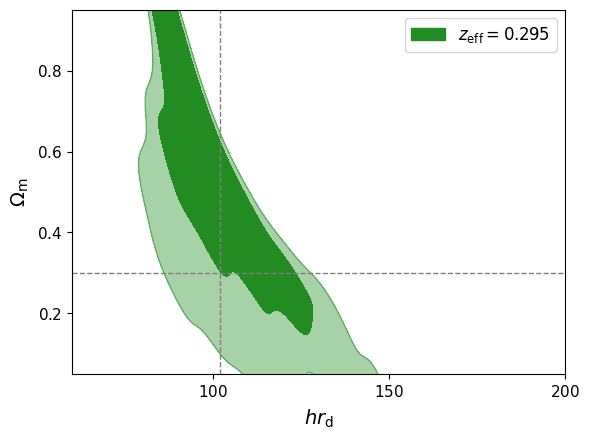

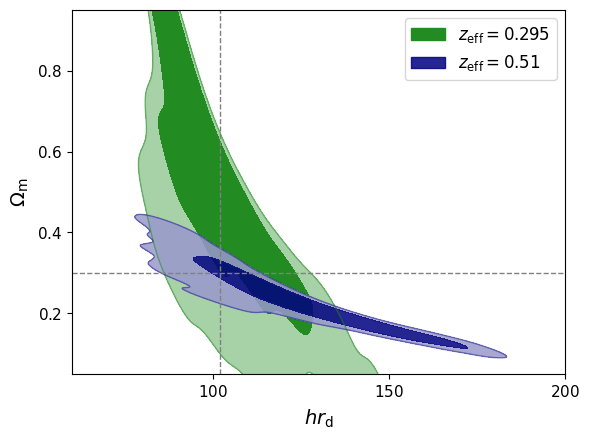

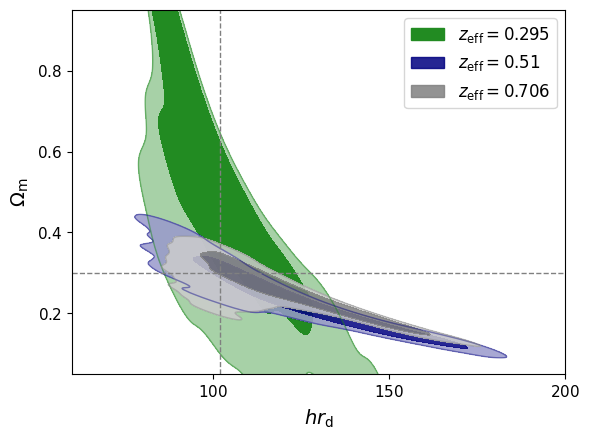

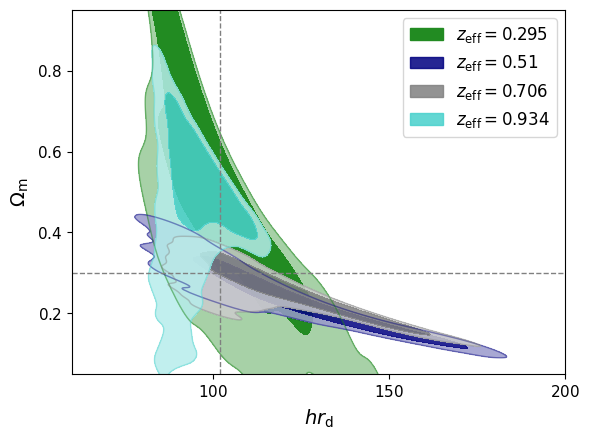

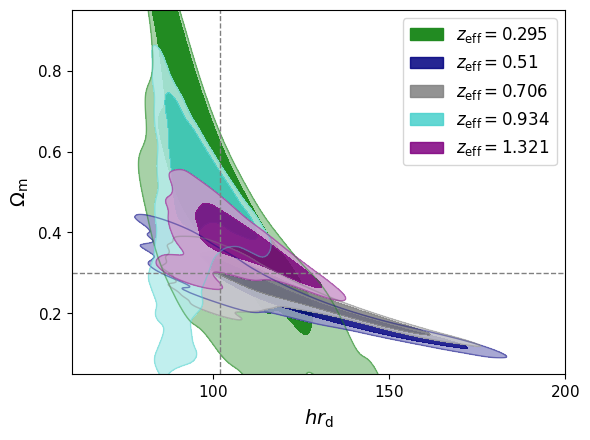

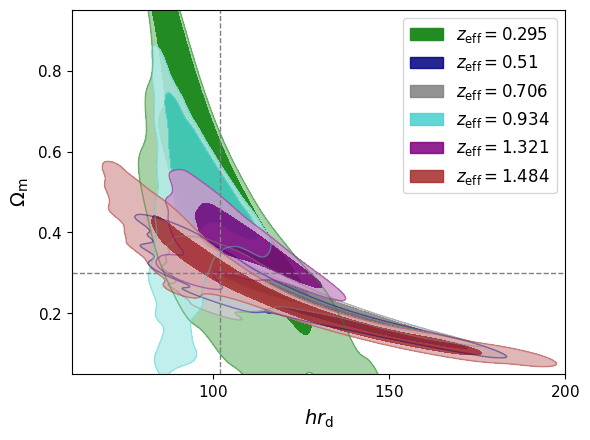

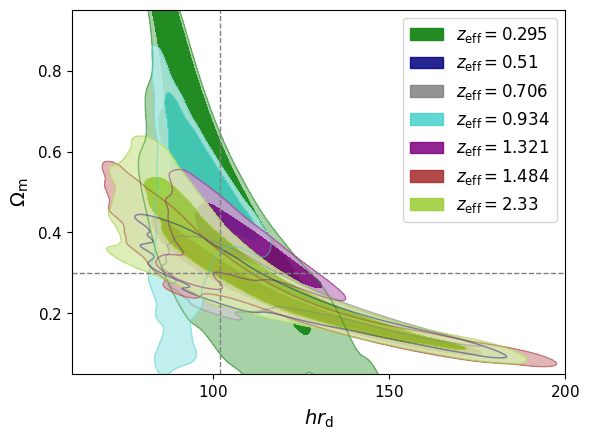

In [19]:
from cobaya import load_samples
redshifts = [1, 2, 3, 4, 5, 6, 7]
# redshifts = [7]
z_values = [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330]
zvalues = [z_values[i-1] for i in redshifts]
colors = ['forestgreen', 'navy', 'gray', 'mediumturquoise', 'purple', 'brown', 'yellowgreen']

gd_sample = [load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z{z}/z{z}", to_getdist=True, skip=0.33) for z in redshifts]
gd_sample[0] = load_samples(f"cobaya_runs/DESI_data/w_wa_individual/z1/z1_2", to_getdist=True, skip=0.33)

names = ["hrdrag", "w", "wa", "omm"] 

for i in range(len(redshifts)):
    # if i ==6:
    # if i ==0:
    gdplot = gdplt.get_single_plotter()
    gdplot.plot_2d(gd_sample[0:i+1], [names[0], names[3]], filled=True, width_inch=4, colors=colors[0:i+1], lims=[60, 200, 0.05, 0.95])
    gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$" for z in z_values])
    gdplot.settings.alpha_filled_add = 1
    # gdplot.settings.alpha_factor_contour_lines = 1  
    # gdplot.settings.linewidth_contour = 2.0
    gdplot.settings.num_plot_contours = 2
    gdplot.add_param_markers({names[0]: 102.15, names[3]: 0.3}, lw=1) 
    gdplot.export(f"figures/DESI_data/w_wa_individual/contours_Om_hrd_z{i+1}.png")